In [1]:
import utils_inverse
%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for BC

## 1. Generate initial parameters, test backpropagation, and create baseline emulator

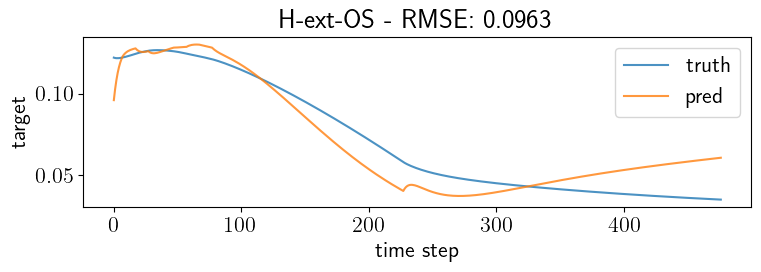

Getting gradient for historical...
	||grad BC||: 0.0008296993328258395
	||grad CH4||: 0.0
	||grad CO2||: 0.0
	||grad N2O||: 0.0
	||grad Sulfur||: 0.0


In [2]:
# Required to generate baseline parameters
agents        = ['BC']       # Forcing agents included in temperatutre simulations
active_agents = ("BC",)       # Forcing agents with active gradients (can differ from above)
hidden_sizes  = [16]          # Dimension of neural network emulator
idx_demo      = 1             # Index of scenario to plot
test_scen     = 'historical'  # Scenario to test backpropagation; gradient printed wrt this scenario
verbose       = False         # Flag to print RMSE values for test

# Generate initial parameters and test backpropagation
params0, emis_dict_train_JAX = utils_inverse.generate_init_params_and_train_data(agents,
                                                                                 active_agents,
                                                                                 test_scen,
                                                                                 hidden_sizes=hidden_sizes,
                                                                                 idx_demo=idx_demo,
                                                                                 verbose=verbose)

In [3]:
# Generate data for emulator evaluation
(eval_sets,
emis_dict_tier1_JAX,
emis_dict_tier2_JAX,
emis_dict_DECK_JAX,
emis_dict_CS3_JAX,
emis_dict_all_JAX) = utils_inverse.generate_eval_data(agents, CS3=True, DAMIP=False, GeoMIP=False)

In [4]:
# Baseline emulator parameters
save_path   = 'checkpoints/BC/baseline_BC_only.pkl' # Location to save baseline data
verbose     = False # Flag to print NRMSE values from the baseline emulator

# Create baseline emulator
baseline_results, baseline_pred_delT, ground_truth_delT = utils_inverse.generate_and_eval_baseline_emulator(emis_dict_tier1_JAX,
                                                                                                            eval_sets, save_path=save_path,
                                                                                                            verbose=verbose, hidden_sizes=hidden_sizes)

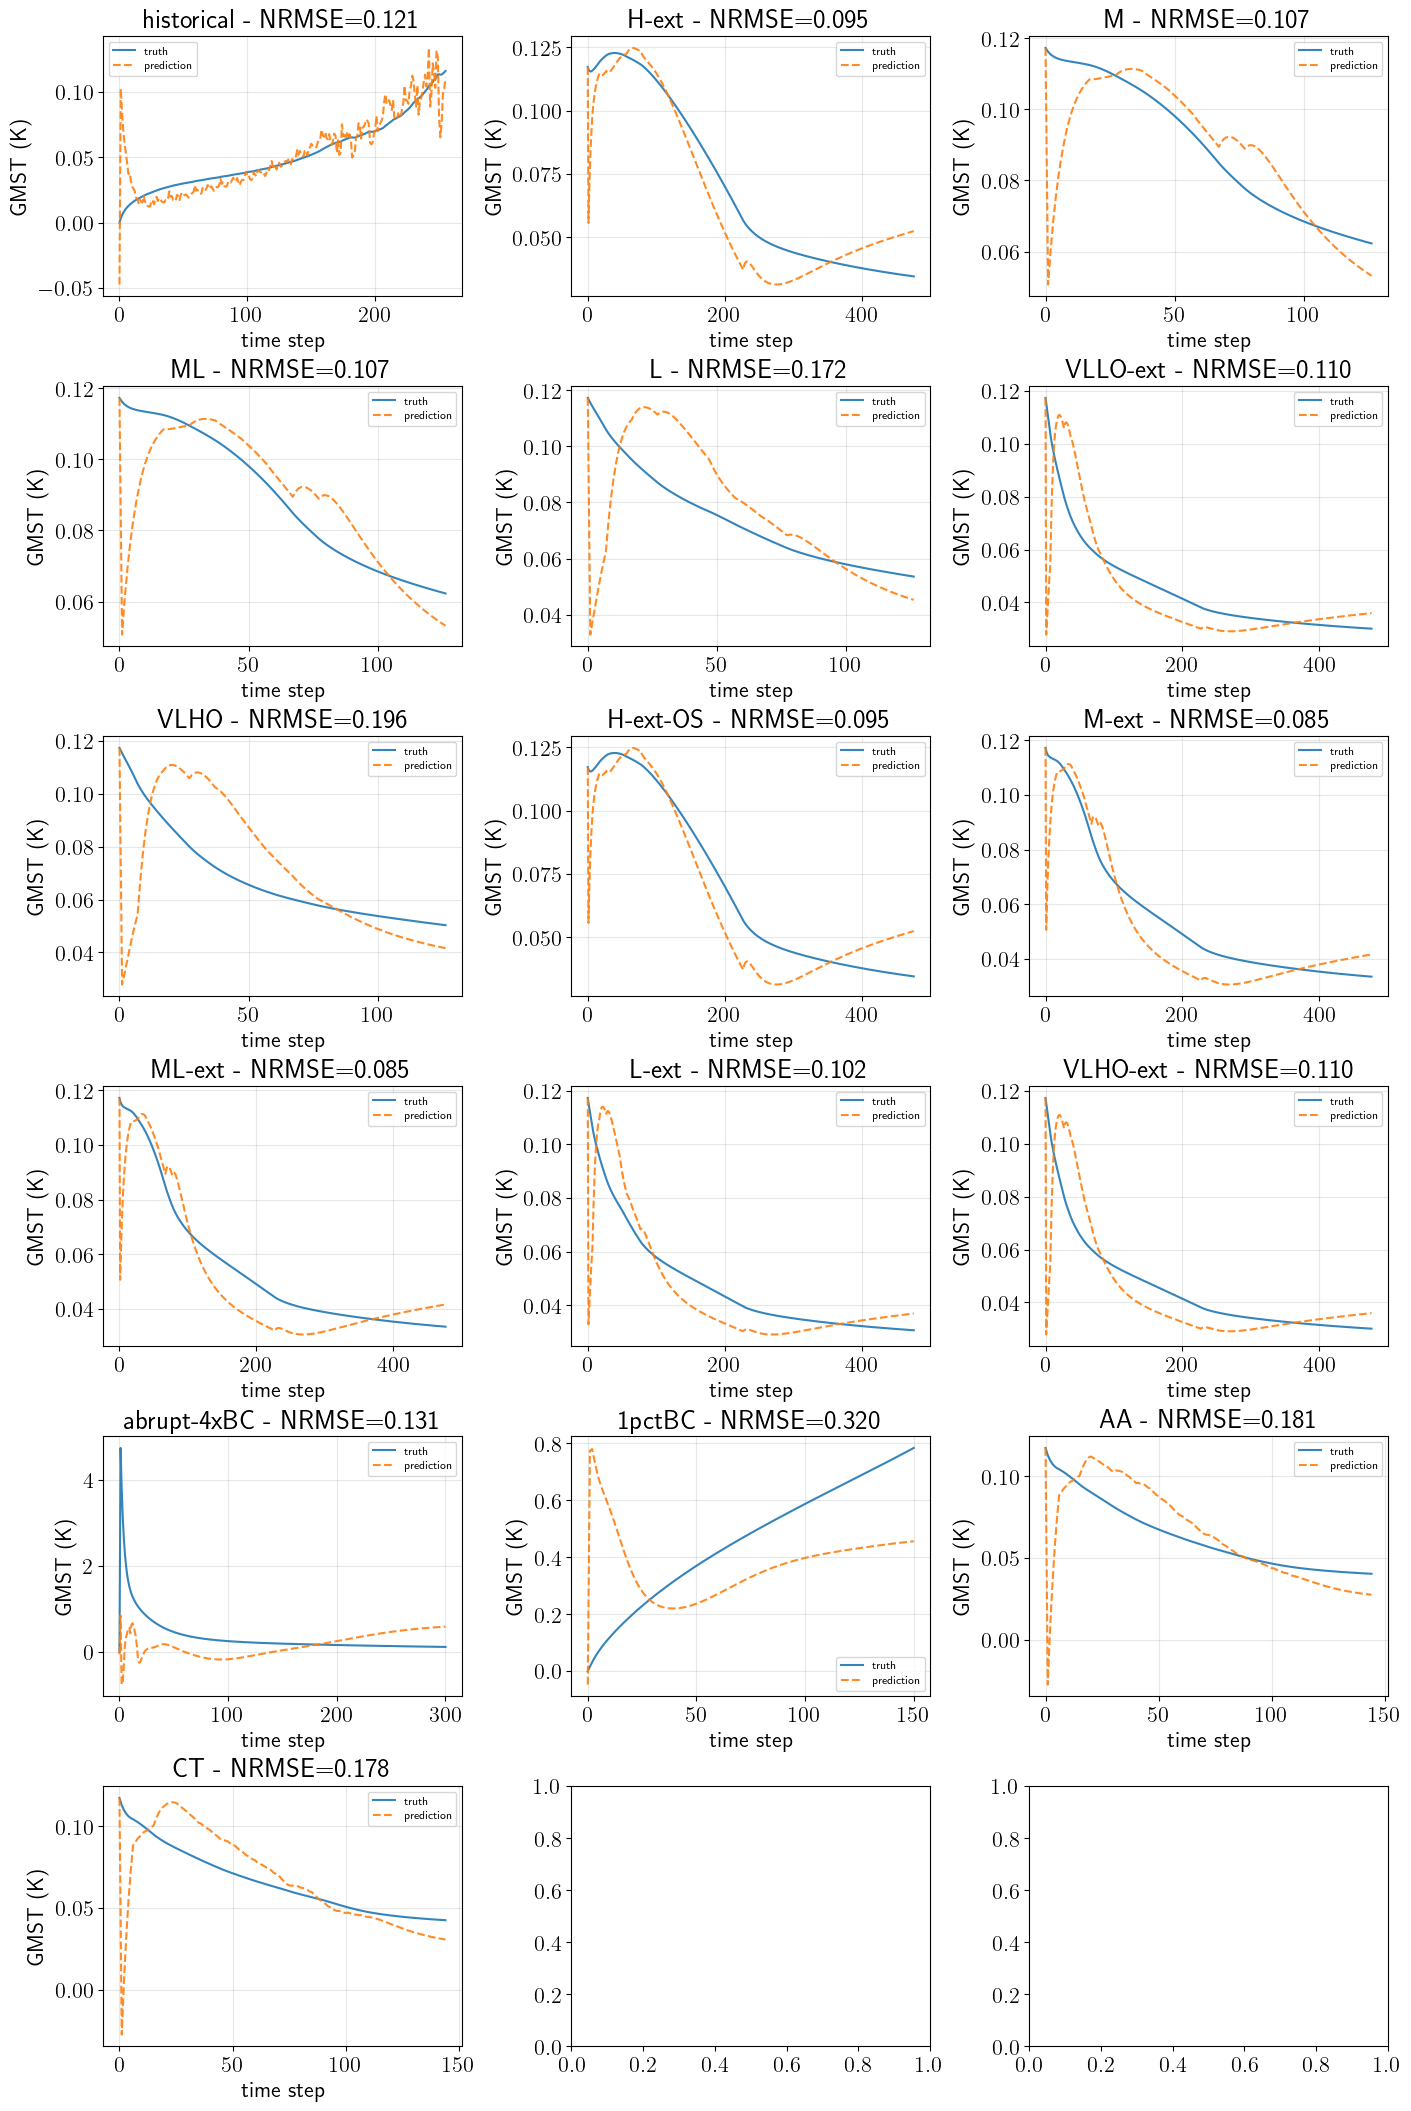

In [5]:
# Optional: plot predictions of baseline emulator
utils_inverse.plot_baseline_pred_delT(baseline_results, baseline_pred_delT, ground_truth_delT)

## 2. Optimize BC emissions time series used in training

### 2a. Optimize for individual scenario (H-ext), starting from constant initial condition

In [6]:
## Create validation data; this is the optimization target
emis_dict_valid                 = {}
emis_dict_valid['H-ext']        = emis_dict_train_JAX['H-ext'].copy()       # High emissions scenario
emis_dict_valid['historical']   = emis_dict_train_JAX['historical'].copy()  # Historical data, required for ScenarioMIP

## Optimization parameters
num_updates     = 1000          # Number of optimization iterations
step_size       = 1e2           # Step size for optimizer, gradients are typically very small
momentum        = 0.9           # Momentum decay rate
nesterov        = True          # Flag to use nesterov momentum in optimization
K_inner         = 400           # Number of gradient descent steps during training
lr_inner        = 5e-2          # Learning rate during training
wd_inner        = 1e-2          # Weight decay (regularization) for training
init_cond       = 'constant'    # Emissions initial condition
T               = 477           # Length of optimized time series
filter_hist     = True          # Flag to not include historical data in the optimization

## Parameters for saving output data
checkpoint_path     = f"checkpoints/BC/inverse_H-ext_{init_cond}_BC_only.pkl" # Location of save data
checkpoint_every    = 50    # How often to save snapshots of the optimization
resume_if_exists    = True  # Flag to continue optimization from saved checkpoint, overwrites existing data if False
preds_every         = 50    # How often to save emulator temperature predictions

## Run optimization algorithm
results_BC_Hext_const = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=num_updates,
    step_size=step_size,
    momentum=momentum,
    nesterov=nesterov,
    K_inner=K_inner,
    lr_inner=lr_inner,
    wd_inner=wd_inner,
    active_agents=active_agents,
    init_cond=init_cond,
    T=T,
    filter_hist=filter_hist,
    checkpoint_path=checkpoint_path,
    checkpoint_every=checkpoint_every,
    resume_if_exists=resume_if_exists,
    preds_every=preds_every,
)

Resuming from checkpoint...


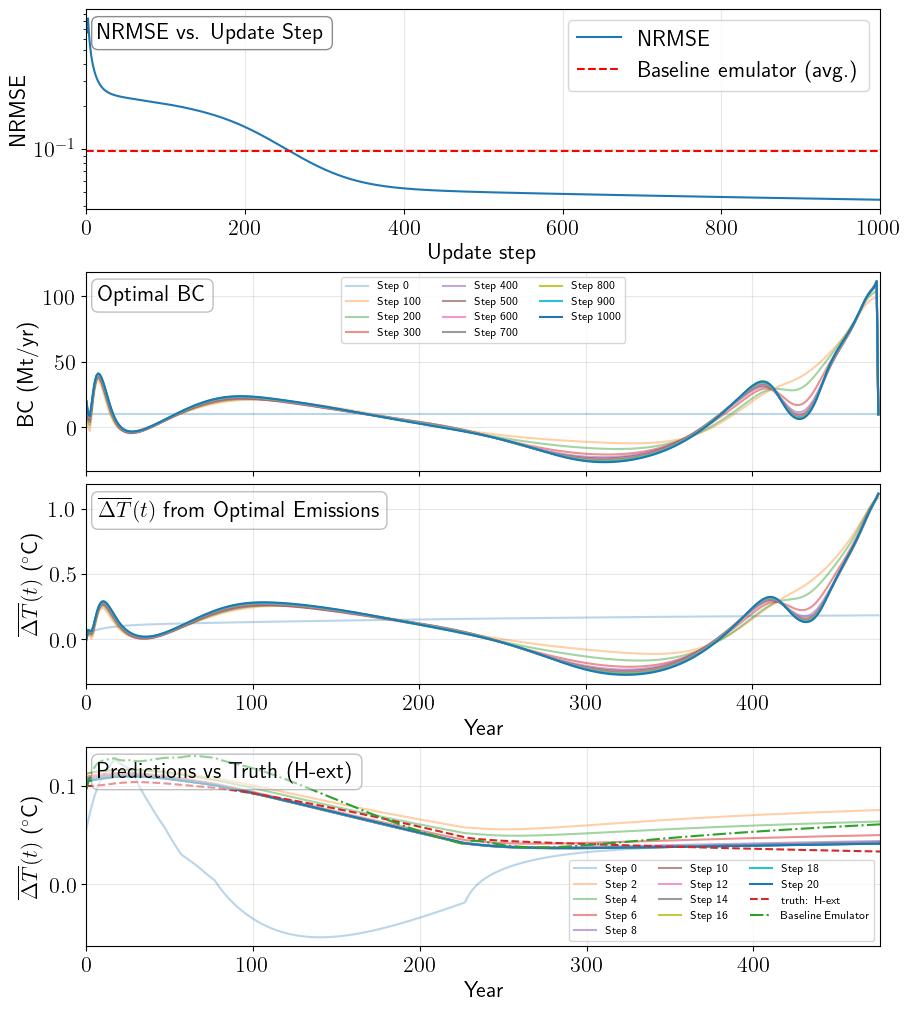

In [7]:
# Optional: plot results of optimization
predict_plot = 'H-ext'

utils_inverse.plot_inverse_results(
    results_BC_Hext_const,
    baseline_results['Tier 1'][predict_plot],
    active_agents=('BC',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT['Tier 1'][predict_plot]
)

### 2b. Optimize training data for predictive skill over all evaluation sets

In [6]:
## Create validation data; this is the optimization target
# Here, we optimize over several sets of scenarios
emis_dicts_valid = [(emis_dict_tier1_JAX.copy(), 'tier1'),
                    (emis_dict_tier2_JAX.copy(), 'tier2'),
                    (emis_dict_DECK_JAX.copy(), 'DECK'),
                    (emis_dict_CS3_JAX.copy(), 'CS3'),
                    (emis_dict_all_JAX.copy(), 'all')]
results_BC_dict = {}

## Optimization parameters
num_updates       = 1000          # Number of optimization iterations
step_size         = 1e2           # Step size for optimizer, gradients are typically very small
momentum          = 0.9           # Momentum decay rate
nesterov          = True          # Flag to use nesterov momentum in optimization
K_inner           = 400           # Number of gradient descent steps during training
lr_inner          = 5e-2          # Learning rate during training
wd_inner          = 1e-2          # Weight decay (regularization) for training
init_cond         = 'constant'    # Emissions initial condition
T                 = 751           # Length of optimized time series
smoothness_weight = 0             # Penalty to prevent sharp gradients in the resulting time series

## Parameters for saving output data
checkpoint_every    = 50    # How often to save snapshots of the optimization
resume_if_exists    = False  # Flag to continue optimization from saved checkpoint, overwrites existing data if False
preds_every         = 50    # How often to save emulator temperature predictions

## Run optimization algorithm
for emis_dict, group in emis_dicts_valid:
  print(f'Optimizing over {group}')

  # Historical scenario only counted as part of tier 1
  if group in ['tier2','CS3']:
    filter_hist = True # Flag to not include historical data in the optimization
  else:
    filter_hist = False

  # Location of save data changes for each set of scenarios
  checkpoint_path = f"checkpoints/BC/inverse_{init_cond}_{group}_BC_only.pkl"

  results_BC_dict[group] = utils_inverse.optimize_emissions_inverse(
      emis_dict=emis_dict,
      params0=params0,
      num_updates=num_updates,
      step_size=step_size,
      momentum=momentum,
      nesterov=nesterov,
      K_inner=K_inner,
      lr_inner=lr_inner,
      wd_inner=wd_inner,
      active_agents=active_agents,
      init_cond=init_cond,
      T=T,
      filter_hist=filter_hist,
      checkpoint_path=checkpoint_path,
      checkpoint_every=checkpoint_every,
      resume_if_exists=resume_if_exists,
      preds_every=preds_every,
      smoothness_weight=smoothness_weight
  )

Optimizing over tier1
Overwriting save data...
Optimizing over tier2
Overwriting save data...
Optimizing over DECK
Overwriting save data...
Optimizing over CS3
Overwriting save data...
Optimizing over all
Overwriting save data...


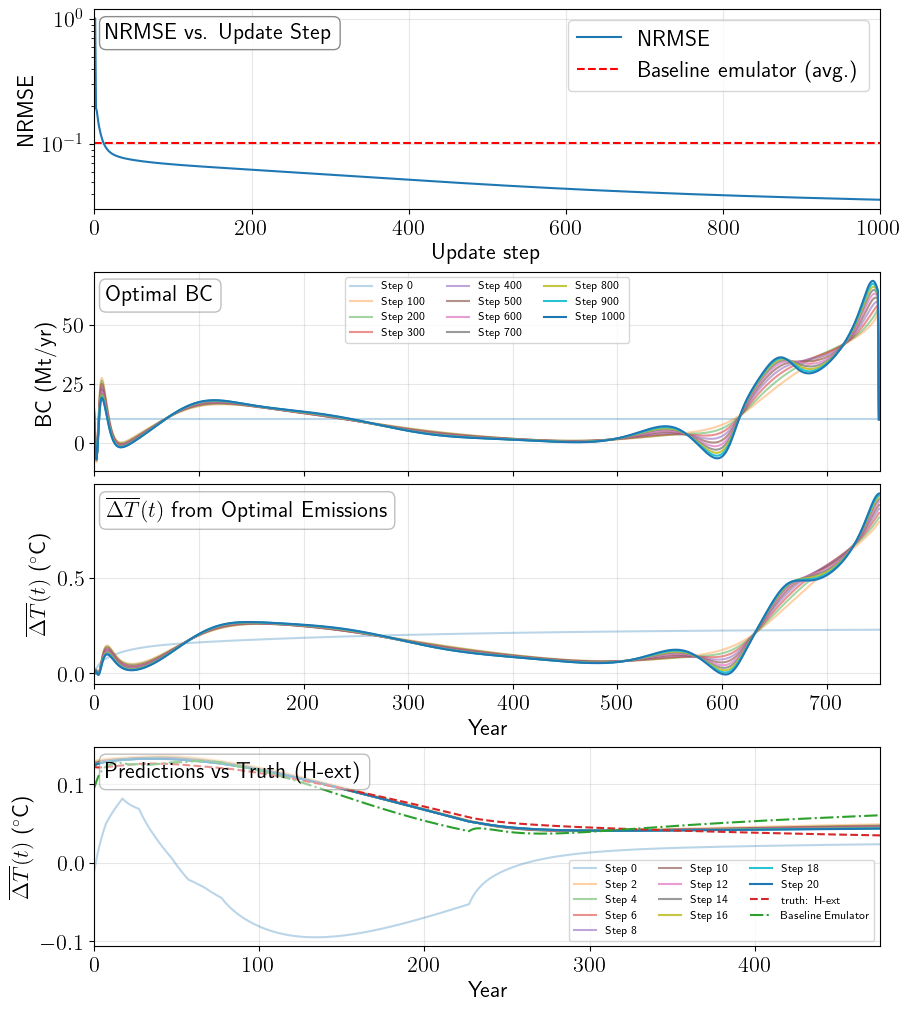

In [7]:
# Optional: plot results of optimization
## Plotting parameters
opt_test        = 'tier1'  # Evaluation set to plot optimized results for
baseline_test   = 'Tier 1' # Evaluation set to plot results for
predict_plot    = 'H-ext'  # Individual scenario to plot predictions

utils_inverse.plot_inverse_results(
    results_BC_dict[opt_test],
    baseline_results[baseline_test]['mean'],
    active_agents=active_agents,
    pred_scenario=predict_plot,
    baseline_preds=baseline_pred_delT[baseline_test][predict_plot]
)